Carga de datos

In [2]:
import pandas as pd

df_clima = pd.read_csv('../../Bases de datos/base_datos.csv')
df_clima = df_clima[df_clima['Año'] >= 2014]
df_dengue= pd.read_csv("../../Bases de datos/Datos_dengue_comletos.csv")

## Coordenadas estaciones 

Calcular pesos de las estaciones 

In [3]:
def normalizar_nombre_provincia(nombre):
    """
    Normaliza el nombre de la provincia para hacer coincidir entre datasets
    """
    if pd.isna(nombre):
        return nombre
    
    correcciones = {
        'Sancti Spíritus': 'Sancti Spiritus',
        'Ciego de Ávila': 'Ciego de Avila',
        'Guantánamo': 'Guantanmo',
        'Isla De La Juventud': 'Isla de la Juventud',
        "Santiago De Cuba":"Santiago de Cuba",
        "Pinar Del Río":"Pinar del Río"
    }
    
    if nombre in correcciones:
        return correcciones[nombre]
    
    return ' '.join([word.capitalize() for word in nombre.split()])

df_clima['Provincias'] = df_clima['Provincias'].apply(normalizar_nombre_provincia)



In [4]:
from calculando_voroni import main
pesos_maestro=main(df_clima,gjson='cuba.geojson')

✅ La Habana: 1 estación detectada (100%)
✅ Matanzas: 3 estaciones calculadas con Voronoi
✅ Cienfuegos: 1 estación detectada (100%)
✅ Sancti Spiritus: 1 estación detectada (100%)
✅ Las Tunas: 1 estación detectada (100%)
✅ Holguín: 3 estaciones calculadas con Voronoi
✅ Granma: 2 estaciones calculadas con Voronoi
✅ Santiago de Cuba: 1 estación detectada (100%)
✅ Isla de la Juventud: 1 estación detectada (100%)
✅ Camagüey: 2 estaciones calculadas con Voronoi
✅ Ciego de Avila: 2 estaciones calculadas con Voronoi
✅ Villa Clara: 1 estación detectada (100%)
✅ Guantanmo: 2 estaciones calculadas con Voronoi
✅ Pinar del Río: 2 estaciones calculadas con Voronoi
✅ Artemisa: 2 estaciones calculadas con Voronoi
✅ Mayabeque: 1 estación detectada (100%)

--- PROCESO COMPLETADO ---
Total de estaciones en el diccionario: 26


Calculando el promedio de estaciones y provincias

In [5]:
df_clima = df_clima[df_clima['Año'] >= 2014]

df_clima['peso'] = df_clima['Nombres Estaciones'].map(pesos_maestro)

variables = ['Temperatura med', 'Humedad Relat', 'Precipitaciones']

for var in variables:
    df_clima[f'{var}_ponderada'] = df_clima[var] * df_clima['peso']

df_provincial = df_clima.groupby(['Provincias', 'Año', 'Mes'])[ 
    [f'{v}_ponderada' for v in variables] 
].sum().reset_index()

df_provincial.columns = ['Provincia', 'Año', 'Mes', 'Temp_Med', 'Hum_Rel', 'Precip']

Transformar a semanal 

In [6]:
from transformar_a_semanal import semanal 
df_clima_t=semanal(df_provincial)

# DENGUe

In [7]:
df_dengue= pd.read_csv("../../Bases de datos/Datos_dengue_comletos.csv")


In [8]:
df_dengue['Fecha'] = pd.to_datetime(
    df_dengue['Año'].astype(str) + 
    df_dengue['Semana Estadística'].astype(str) + '1', 
    format='%Y%W%w'
)

df_dengue = df_dengue.drop(columns=['Unnamed: 0'])

id_vars = ['Año', 'Semana Estadística', 'Fecha']
value_vars = [col for col in df_dengue.columns if col not in id_vars]

df_dengue_largo = pd.melt(
    df_dengue,
    id_vars=id_vars,
    value_vars=value_vars,
    var_name='Provincias',  # Nombre para la nueva columna de provincias
    value_name='Casos_Dengue' # Nombre para la nueva columna de casos
)

print("\n--- DataFrame de Dengue Transformado a Formato Largo ---")
print(df_dengue_largo.head(10))


--- DataFrame de Dengue Transformado a Formato Largo ---
    Año  Semana Estadística      Fecha     Provincias  Casos_Dengue
0  2014                   1 2014-01-06  Pinar Del Río           0.0
1  2014                   2 2014-01-13  Pinar Del Río           0.0
2  2014                   3 2014-01-20  Pinar Del Río           0.0
3  2014                   4 2014-01-27  Pinar Del Río           0.0
4  2014                   5 2014-02-03  Pinar Del Río           0.0
5  2014                   8 2014-02-24  Pinar Del Río           0.0
6  2014                   9 2014-03-03  Pinar Del Río           0.0
7  2014                  11 2014-03-17  Pinar Del Río           0.0
8  2014                  12 2014-03-24  Pinar Del Río           0.0
9  2014                  13 2014-03-31  Pinar Del Río           0.0


In [67]:
df_clima_t

,Provincia,Fecha,Temp_Med,Hum_Rel,Precip,Año,Mes
0,Artemisa,2014-01-06,21.7500,78.000,28.175,2014,1
1,Artemisa,2014-01-13,22.2375,77.875,28.175,2014,1
2,Artemisa,2014-01-20,22.7250,77.750,28.175,2014,1
3,Artemisa,2014-01-27,23.2125,77.625,28.175,2014,1
4,Artemisa,2014-02-03,23.7000,77.500,18.700,2014,2
...,...,...,...,...,...,...,...
7451,Villa Clara,2022-11-07,24.6000,83.000,15.500,2022,11
7452,Villa Clara,2022-11-14,24.0000,82.250,15.500,2022,11
7453,Villa Clara,2022-11-21,23.4000,81.500,15.500,2022,11
7454,Villa Clara,2022-11-28,22.8000,80.750,15.500,2022,11


In [21]:
def normalizar_nombre_provincia(nombre):
    """
    Normaliza el nombre de la provincia para hacer coincidir entre datasets
    """
    if pd.isna(nombre):
        return nombre
    
    correcciones = {
        'Pinar Del Río': 'Pinar del Río',
        'Isla De La Juventud': 'Isla de la Juventud',
        'Ciego De Avila': 'Ciego de Ávila',
        'Santiago De Cuba': 'Santiago de Cuba',
        'Guantanmo':'Guantánamo',
        'Ciego De Ávila':'Ciego de Ávila',
        'Sancti Spiritus':'Sancti Spíritus',
    }
    
    if nombre in correcciones:
        return correcciones[nombre]
    
    return ' '.join([word.capitalize() for word in nombre.split()])

# df_dengue_largo['Provincias'] = df_dengue_largo['Provincias'].apply(normalizar_nombre_provincia)
df_clima_t['Provincias']= df_clima_t['Provincias'].apply(normalizar_nombre_provincia)

print("Provincias dengue (normalizadas):")
print(df_dengue_largo['Provincias'].unique())
print("\nProvincias clima (normalizadas):")
print(df_clima_t['Provincias'].unique())

Provincias dengue (normalizadas):
['Pinar del Río' 'Artemisa' 'La Habana' 'Mayabeque' 'Matanzas'
 'Cienfuegos' 'Villa Clara' 'Sancti Spíritus' 'Ciego de Ávila' 'Camagüey'
 'Las Tunas' 'Holguín' 'Granma' 'Santiago de Cuba' 'Guantánamo'
 'Isla de la Juventud']

Provincias clima (normalizadas):
['Artemisa' 'Camagüey' 'Ciego de Ávila' 'Cienfuegos' 'Granma' 'Guantánamo'
 'Holguín' 'Isla de la Juventud' 'La Habana' 'Las Tunas' 'Matanzas'
 'Mayabeque' 'Pinar del Río' 'Sancti Spíritus' 'Santiago de Cuba'
 'Villa Clara']


In [10]:
df_dengue_predicciones=df_dengue_largo[df_dengue_largo["Año"]>2022]
df_dengue_largo=df_dengue_largo[df_dengue_largo["Año"]<=2022]
df_clima_t = df_clima_t.rename(columns={"Provincia": "Provincias"})

In [22]:
lista_procesada=[]
for provincia in df_clima_t['Provincias'].unique():
    print(f"--- Procesando provincia: {provincia} ---")
    
    dengue_prov = df_dengue_largo[df_dengue_largo['Provincias'] == provincia].copy()
    clima_prov = df_clima_t[df_clima_t['Provincias'] == provincia].copy()
        
    df_unido = pd.merge(dengue_prov, clima_prov, on=['Fecha', 'Provincias'], how='left')
    print(df_unido)
    lista_procesada.append(df_unido)
    
df_final = pd.concat(lista_procesada)


--- Procesando provincia: Artemisa ---
     Año_x  Semana Estadística      Fecha Provincias  Casos_Dengue  Temp_Med  \
0     2014                   1 2014-01-06   Artemisa           0.0   21.7500   
1     2014                   2 2014-01-13   Artemisa           0.0   22.2375   
2     2014                   3 2014-01-20   Artemisa           0.0   22.7250   
3     2014                   4 2014-01-27   Artemisa           0.0   23.2125   
4     2014                   5 2014-02-03   Artemisa           0.0   23.7000   
..     ...                 ...        ...        ...           ...       ...   
453   2022                  48 2022-11-28   Artemisa          37.0   24.0625   
454   2022                  49 2022-12-05   Artemisa          28.0   23.4500   
455   2022                  50 2022-12-12   Artemisa          24.0       NaN   
456   2022                  51 2022-12-19   Artemisa          19.0       NaN   
457   2022                  52 2022-12-26   Artemisa          15.0       NaN   



In [23]:
import pandas as pd

diccionario_de_dataframes = {}

for provincia in df_clima_t['Provincias'].unique():
    print(f"Procesando: {provincia}...")
    
    dengue_prov = df_dengue_largo[df_dengue_largo['Provincias'] == provincia].copy()
    clima_prov = df_clima_t[df_clima_t['Provincias'] == provincia].copy()
     
    
    df_procesado = pd.merge(dengue_prov, clima_prov, on=['Fecha', 'Provincias'], how='left')
    
    df_procesado.dropna(inplace=True)
    
    if not df_procesado.empty:
        diccionario_de_dataframes[provincia] = df_procesado
        print(f"  -> DataFrame para '{provincia}' guardado con {len(df_procesado)} filas.")
    else:
        print(f"  -> ADVERTENCIA: El DataFrame para '{provincia}' quedó vacío.")

print("\n¡Proceso completado!")
print(f"Se han creado DataFrames para {len(diccionario_de_dataframes)} provincias.")


Procesando: Artemisa...
  -> DataFrame para 'Artemisa' guardado con 455 filas.
Procesando: Camagüey...
  -> DataFrame para 'Camagüey' guardado con 455 filas.
Procesando: Ciego de Ávila...
  -> DataFrame para 'Ciego de Ávila' guardado con 455 filas.
Procesando: Cienfuegos...
  -> DataFrame para 'Cienfuegos' guardado con 455 filas.
Procesando: Granma...
  -> DataFrame para 'Granma' guardado con 455 filas.
Procesando: Guantánamo...
  -> DataFrame para 'Guantánamo' guardado con 443 filas.
Procesando: Holguín...
  -> DataFrame para 'Holguín' guardado con 455 filas.
Procesando: Isla de la Juventud...
  -> DataFrame para 'Isla de la Juventud' guardado con 455 filas.
Procesando: La Habana...
  -> DataFrame para 'La Habana' guardado con 455 filas.
Procesando: Las Tunas...
  -> DataFrame para 'Las Tunas' guardado con 455 filas.
Procesando: Matanzas...
  -> DataFrame para 'Matanzas' guardado con 455 filas.
Procesando: Mayabeque...
  -> DataFrame para 'Mayabeque' guardado con 455 filas.
Procesando

In [129]:
import os

# Crear una carpeta para guardar los archivos si no existe
carpeta_salida = 'dataframes_provincias'
os.makedirs(carpeta_salida, exist_ok=True)

for provincia, df in diccionario_de_dataframes.items():
    ruta_archivo = os.path.join(carpeta_salida, f'{provincia.replace(" ", "_")}.csv')
    df.to_csv(ruta_archivo) 
    print(f"DataFrame de '{provincia}' guardado en '{ruta_archivo}'")

print(f"\n¡Todos los DataFrames se guardaron en la carpeta '{carpeta_salida}'!")

DataFrame de 'Artemisa' guardado en 'dataframes_provincias/Artemisa.csv'
DataFrame de 'Camagüey' guardado en 'dataframes_provincias/Camagüey.csv'
DataFrame de 'Ciego de Ávila' guardado en 'dataframes_provincias/Ciego_de_Ávila.csv'
DataFrame de 'Cienfuegos' guardado en 'dataframes_provincias/Cienfuegos.csv'
DataFrame de 'Granma' guardado en 'dataframes_provincias/Granma.csv'
DataFrame de 'Guantánamo' guardado en 'dataframes_provincias/Guantánamo.csv'
DataFrame de 'Holguín' guardado en 'dataframes_provincias/Holguín.csv'
DataFrame de 'Isla de la Juventud' guardado en 'dataframes_provincias/Isla_de_la_Juventud.csv'
DataFrame de 'La Habana' guardado en 'dataframes_provincias/La_Habana.csv'
DataFrame de 'Las Tunas' guardado en 'dataframes_provincias/Las_Tunas.csv'
DataFrame de 'Matanzas' guardado en 'dataframes_provincias/Matanzas.csv'
DataFrame de 'Mayabeque' guardado en 'dataframes_provincias/Mayabeque.csv'
DataFrame de 'Pinar del Río' guardado en 'dataframes_provincias/Pinar_del_Río.csv'

In [24]:
df_final = df_final.rename(columns={"Precip": "Precipitaciones","Temp_Med":"Temperatura med","Hum_Rel":'Humedad Relat'})
df_final

,Año_x,Semana Estadística,Fecha,Provincias,Casos_Dengue,Temperatura med,Humedad Relat,Precipitaciones,Año_y,Mes
0,2014,1,2014-01-06,Artemisa,0.0,21.7500,78.000,28.175,2014.0,1.0
1,2014,2,2014-01-13,Artemisa,0.0,22.2375,77.875,28.175,2014.0,1.0
2,2014,3,2014-01-20,Artemisa,0.0,22.7250,77.750,28.175,2014.0,1.0
3,2014,4,2014-01-27,Artemisa,0.0,23.2125,77.625,28.175,2014.0,1.0
4,2014,5,2014-02-03,Artemisa,0.0,23.7000,77.500,18.700,2014.0,2.0
...,...,...,...,...,...,...,...,...,...,...
453,2022,48,2022-11-28,Villa Clara,235.0,22.8000,80.750,15.500,2022.0,11.0
454,2022,49,2022-12-05,Villa Clara,193.0,22.2000,80.000,28.500,2022.0,12.0
455,2022,50,2022-12-12,Villa Clara,180.0,NaN,NaN,NaN,NaN,NaN
456,2022,51,2022-12-19,Villa Clara,158.0,NaN,NaN,NaN,NaN,NaN


# Correlacion CCF

In [34]:
df_final

,Año_x,Semana Estadística,Fecha,Provincias,Casos_Dengue,Temperatura med,Humedad Relat,Precipitaciones,Año_y,Mes
0,2014,1,2014-01-06,Artemisa,0.0,21.7500,78.000,28.175,2014.0,1.0
1,2014,2,2014-01-13,Artemisa,0.0,22.2375,77.875,28.175,2014.0,1.0
2,2014,3,2014-01-20,Artemisa,0.0,22.7250,77.750,28.175,2014.0,1.0
3,2014,4,2014-01-27,Artemisa,0.0,23.2125,77.625,28.175,2014.0,1.0
4,2014,5,2014-02-03,Artemisa,0.0,23.7000,77.500,18.700,2014.0,2.0
...,...,...,...,...,...,...,...,...,...,...
453,2022,48,2022-11-28,Villa Clara,235.0,22.8000,80.750,15.500,2022.0,11.0
454,2022,49,2022-12-05,Villa Clara,193.0,22.2000,80.000,28.500,2022.0,12.0
455,2022,50,2022-12-12,Villa Clara,180.0,NaN,NaN,NaN,NaN,NaN
456,2022,51,2022-12-19,Villa Clara,158.0,NaN,NaN,NaN,NaN,NaN


In [38]:
from statsmodels.tsa.stattools import adfuller
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def prueba_estacionariedad(serie, nombre="Serie", alpha=0.05):
    """
    Realiza la prueba ADF y devuelve un diagnóstico completo
    
    Parámetros:
    - serie: la serie temporal a evaluar
    - nombre: nombre para mostrar en resultados
    - alpha: nivel de significancia (generalmente 0.05)
    """
    
    serie_limpia = serie.dropna()

    
    resultado = adfuller(serie_limpia, autolag='AIC')
    
    estadistico_adf = resultado[0]
    p_valor = resultado[1]
    valor_critico_1 = resultado[4]['1%']
    valor_critico_5 = resultado[4]['5%']
    valor_critico_10 = resultado[4]['10%']
    
    es_estacionaria = p_valor < alpha
    
    print(f"\n📊 PRUEBA ADF PARA: {nombre}")
    print(f"   Estadístico ADF: {estadistico_adf:.6f}")
    print(f"   Valor p: {p_valor:.6f}")
    print(f"   Valores críticos:")
    print(f"      1%: {valor_critico_1:.3f}")
    print(f"      5%: {valor_critico_5:.3f}")
    print(f"      10%: {valor_critico_10:.3f}")
    
    if es_estacionaria:
        print(f"   ✅ CONCLUSIÓN: La serie ES estacionaria (p < {alpha})")
        print(f"   ➡️  d sugerido = 0 (no necesita diferenciación)")
    else:
        print(f"   ❌ CONCLUSIÓN: La serie NO es estacionaria (p >= {alpha})")
        print(f"   ➡️  d sugerido = 1 (necesita al menos una diferenciación)")
    
    return {
        'estadistico': estadistico_adf,
        'p_valor': p_valor,
        'es_estacionaria': es_estacionaria,
        'd_sugerido': 0 if es_estacionaria else 1
    }

for provincia, df in diccionario_de_dataframes.items():
    print(f"\n{'='*60}")
    prueba_estacionariedad(df['Casos_Dengue'], provincia)



📊 PRUEBA ADF PARA: Artemisa
   Estadístico ADF: -4.461255
   Valor p: 0.000231
   Valores críticos:
      1%: -3.445
      5%: -2.868
      10%: -2.570
   ✅ CONCLUSIÓN: La serie ES estacionaria (p < 0.05)
   ➡️  d sugerido = 0 (no necesita diferenciación)


📊 PRUEBA ADF PARA: Camagüey
   Estadístico ADF: -2.650071
   Valor p: 0.083084
   Valores críticos:
      1%: -3.445
      5%: -2.868
      10%: -2.570
   ❌ CONCLUSIÓN: La serie NO es estacionaria (p >= 0.05)
   ➡️  d sugerido = 1 (necesita al menos una diferenciación)


📊 PRUEBA ADF PARA: Ciego de Ávila
   Estadístico ADF: -4.281518
   Valor p: 0.000478
   Valores críticos:
      1%: -3.445
      5%: -2.868
      10%: -2.570
   ✅ CONCLUSIÓN: La serie ES estacionaria (p < 0.05)
   ➡️  d sugerido = 0 (no necesita diferenciación)


📊 PRUEBA ADF PARA: Cienfuegos
   Estadístico ADF: -6.170440
   Valor p: 0.000000
   Valores críticos:
      1%: -3.445
      5%: -2.868
      10%: -2.570
   ✅ CONCLUSIÓN: La serie ES estacionaria (p < 0.0

In [40]:
from statsmodels.tsa.stattools import adfuller

def verificar_estacionariedad(serie, nombre):
    result = adfuller(serie.dropna(),autolag='AIC')
    print(f'--- Prueba ADF para {nombre} ---')
    print(f'Estadístico ADF: {result[0]:.4f}')
    print(f'p-valor: {result[1]:.4f}')
    if result[1] <= 0.05:
        print("Resultado: Es Estacionaria (Rechazamos H0)")
    else:
        print("Resultado: NO es Estacionaria (No rechazamos H0)")
    print("-" * 30)
    
df_combinado=df_final
if 'Provincias' not in df_combinado.columns:
    df_combinado = df_combinado.reset_index()
provincias = df_combinado['Provincias'].unique()
variables_climaticas = ['Precipitaciones', 'Temperatura med', 'Humedad Relat']
# df_combinado["Matanzas"]=df_combinado["Matanzas"].diff().dropna()

for provincia in provincias:
    df_provincia = df_combinado[df_combinado['Provincias'] == provincia].copy()
    df_provincia = df_provincia.sort_index()

    serie_dengue = df_provincia['Casos_Dengue']
    
    if provincia == "Matanzas":
        print("⚠️ Aplicando diferenciación (diff) a Matanzas para corregir estacionariedad.")
        serie_dengue = serie_dengue.diff().dropna()   
        verificar_estacionariedad(serie_dengue, 'Dengue')
    else:
        print(f"--- Analizando CCF para: {provincia} ---")
        df_provincia = df_combinado[df_combinado['Provincias'] == provincia]
        
        # Asegurarse de que el índice es una fecha para ordenar correctamente
        df_provincia = df_provincia.sort_index()
        verificar_estacionariedad(df_provincia['Casos_Dengue'], 'Dengue')
    for variable in variables_climaticas:
        verificar_estacionariedad(df_provincia[variable], variable)
    



--- Analizando CCF para: Artemisa ---
--- Prueba ADF para Dengue ---
Estadístico ADF: -3.7622
p-valor: 0.0033
Resultado: Es Estacionaria (Rechazamos H0)
------------------------------
--- Prueba ADF para Precipitaciones ---
Estadístico ADF: -5.0988
p-valor: 0.0000
Resultado: Es Estacionaria (Rechazamos H0)
------------------------------
--- Prueba ADF para Temperatura med ---
Estadístico ADF: -5.0290
p-valor: 0.0000
Resultado: Es Estacionaria (Rechazamos H0)
------------------------------
--- Prueba ADF para Humedad Relat ---
Estadístico ADF: -4.0008
p-valor: 0.0014
Resultado: Es Estacionaria (Rechazamos H0)
------------------------------
--- Analizando CCF para: Camagüey ---
--- Prueba ADF para Dengue ---
Estadístico ADF: -3.3682
p-valor: 0.0121
Resultado: Es Estacionaria (Rechazamos H0)
------------------------------
--- Prueba ADF para Precipitaciones ---
Estadístico ADF: -5.7599
p-valor: 0.0000
Resultado: Es Estacionaria (Rechazamos H0)
------------------------------
--- Prueba ADF

⚠️ Aplicando diff() a  Artemisa


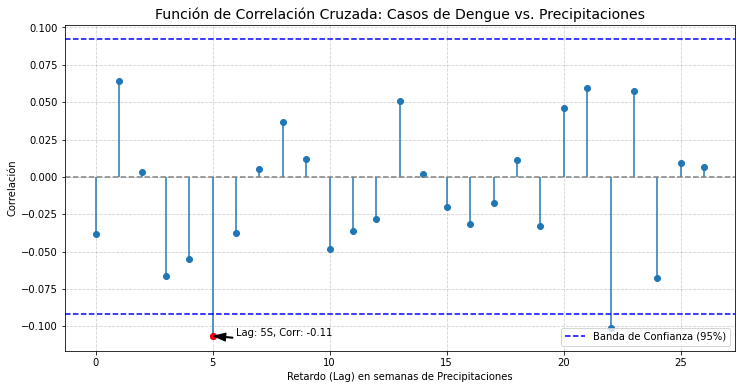

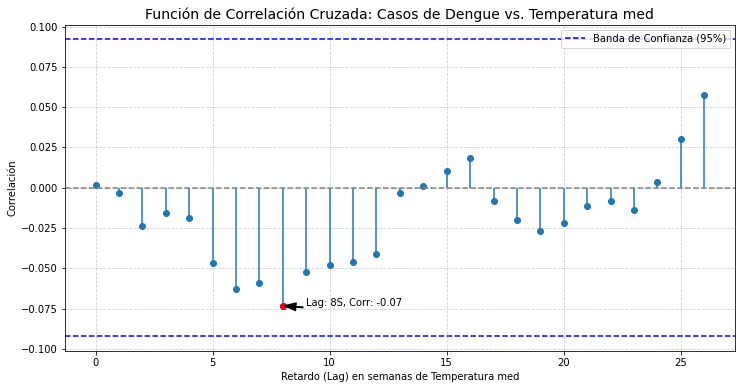

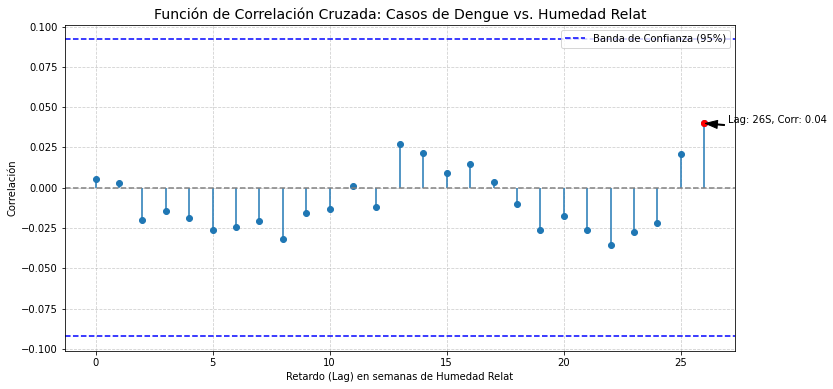

⚠️ Aplicando diff() a  Camagüey


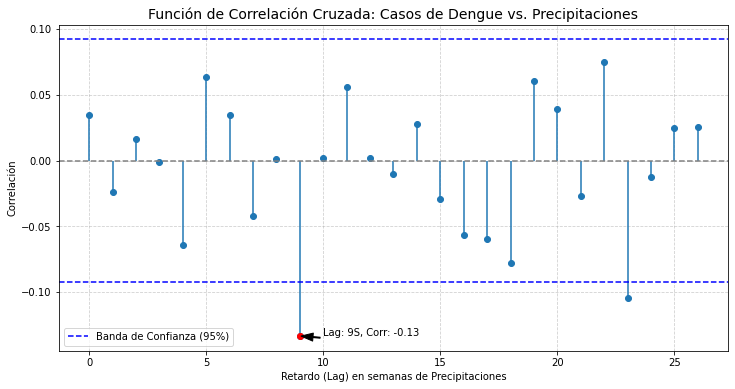

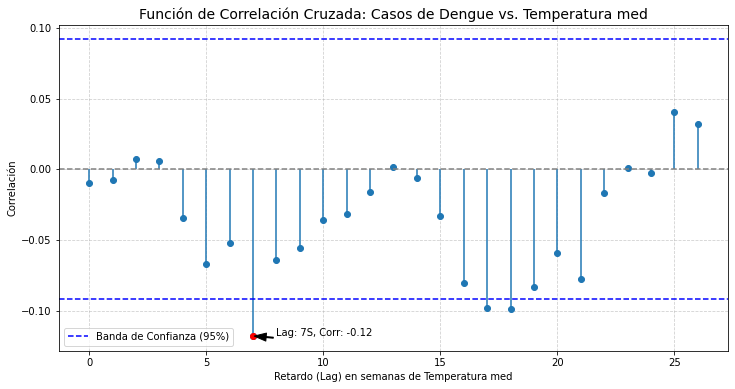

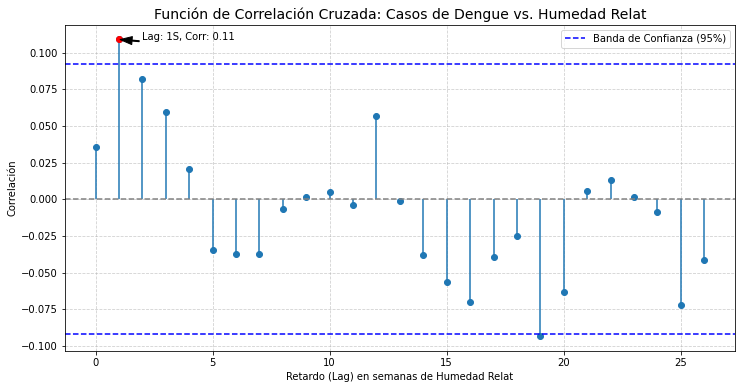

⚠️ Aplicando diff() a  Ciego de Ávila


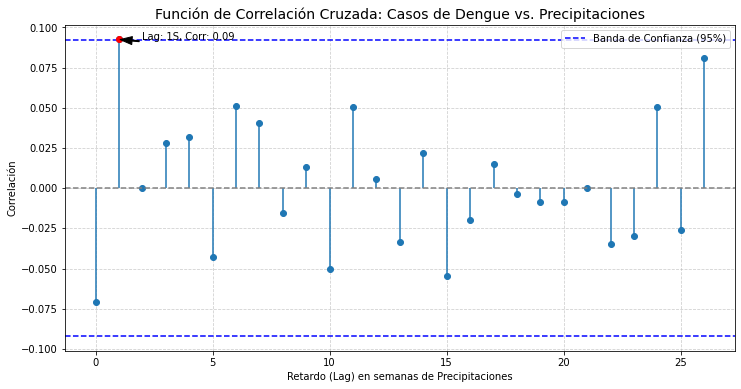

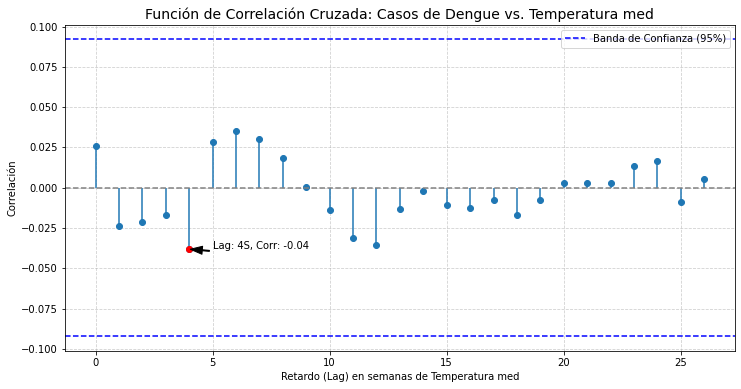

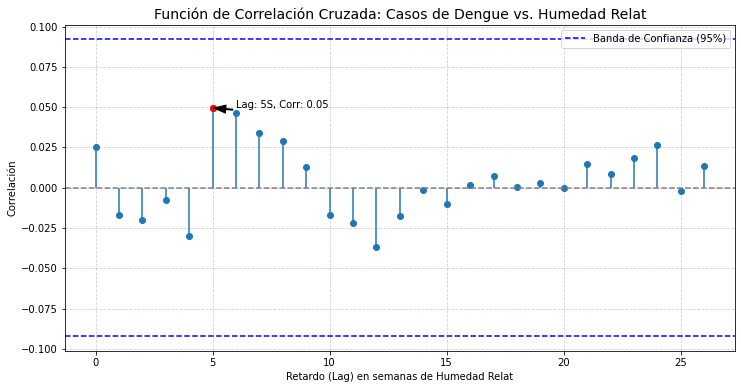

⚠️ Aplicando diff() a  Cienfuegos


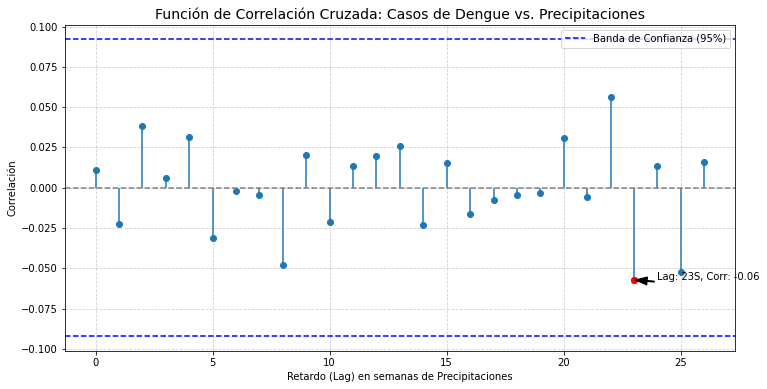

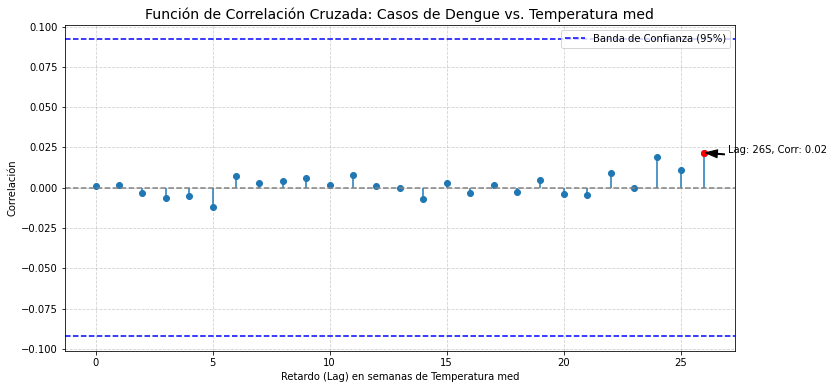

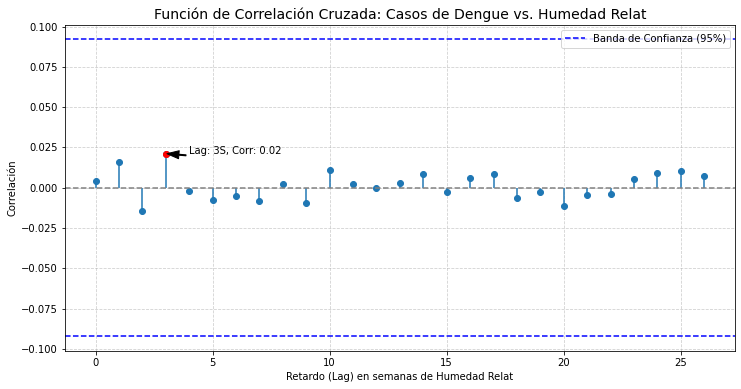

⚠️ Aplicando diff() a  Granma


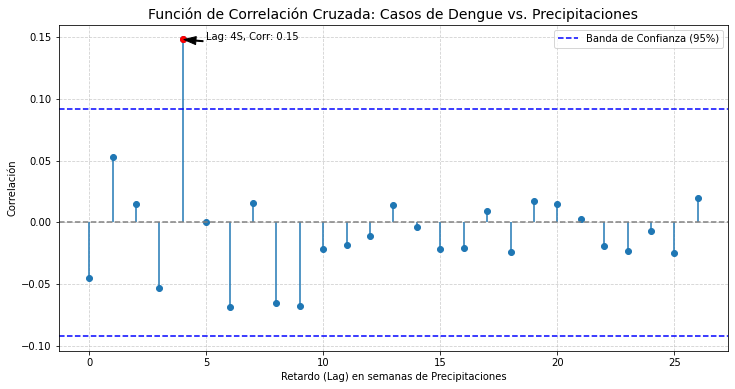

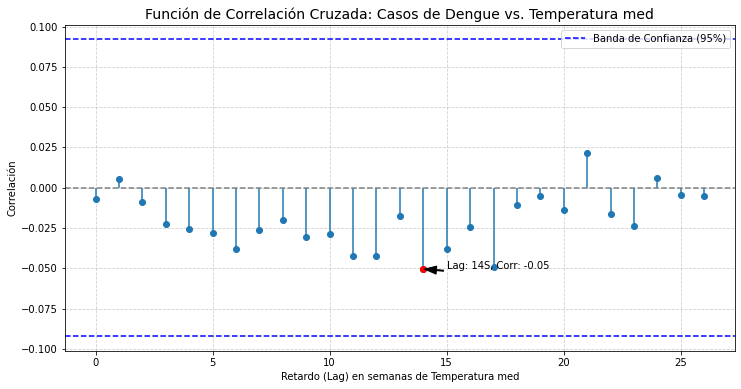

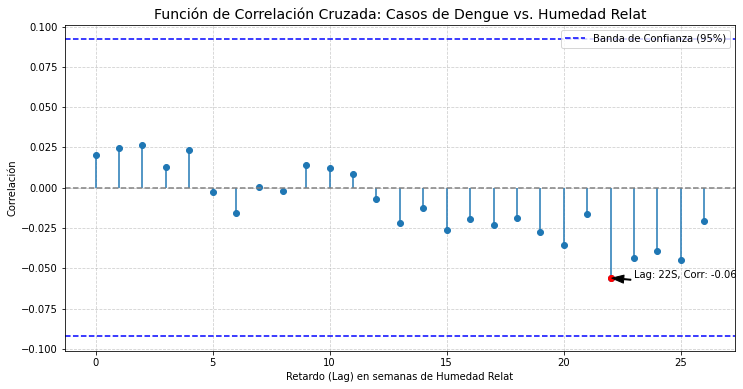

⚠️ Aplicando diff() a  Guantánamo


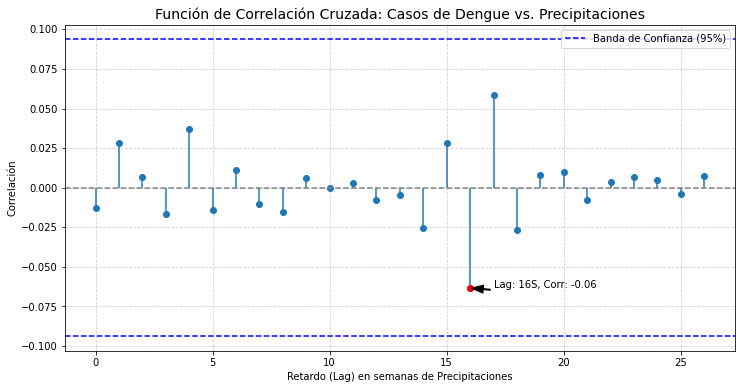

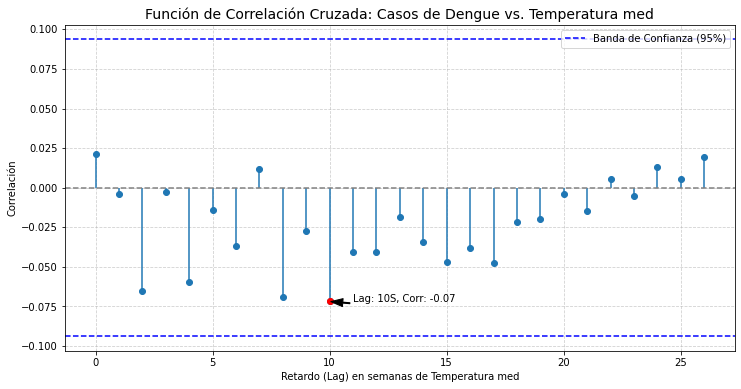

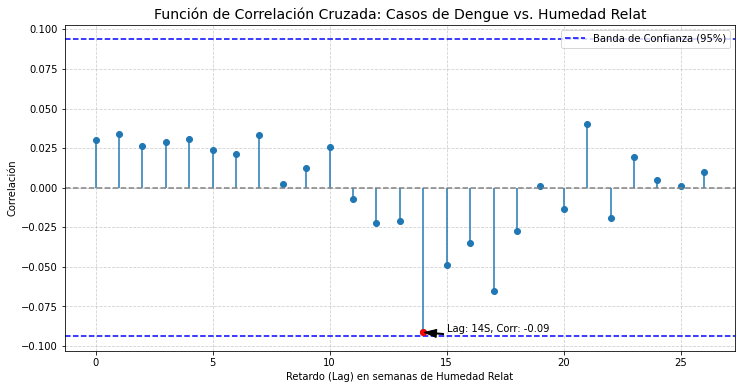

⚠️ Aplicando diff() a  Holguín


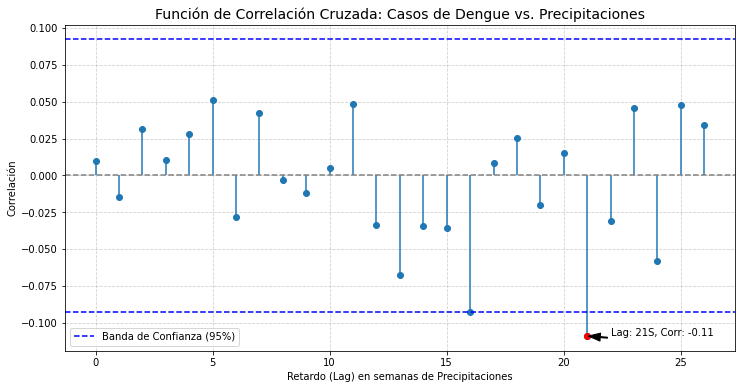

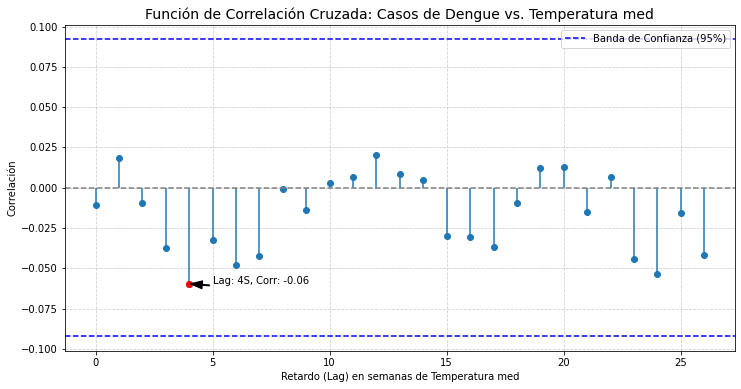

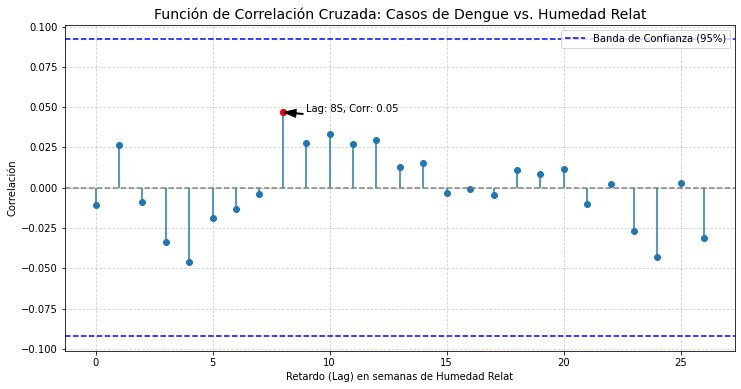

⚠️ Aplicando diff() a  Isla de la Juventud


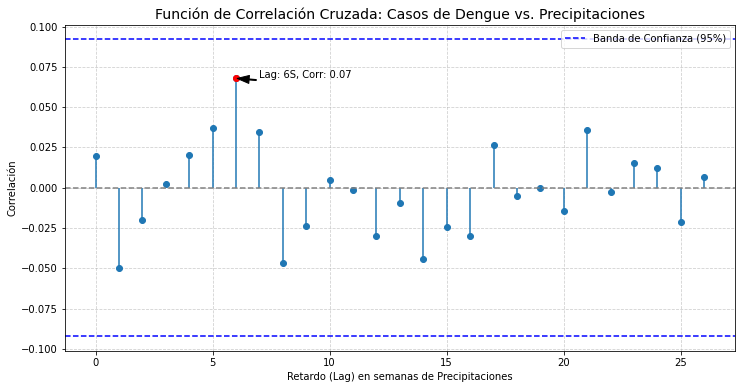

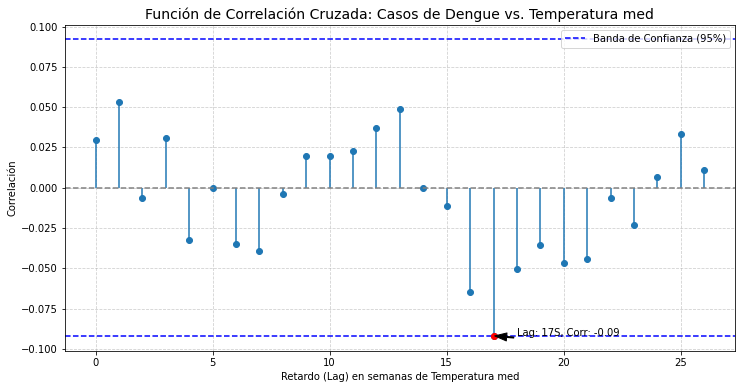

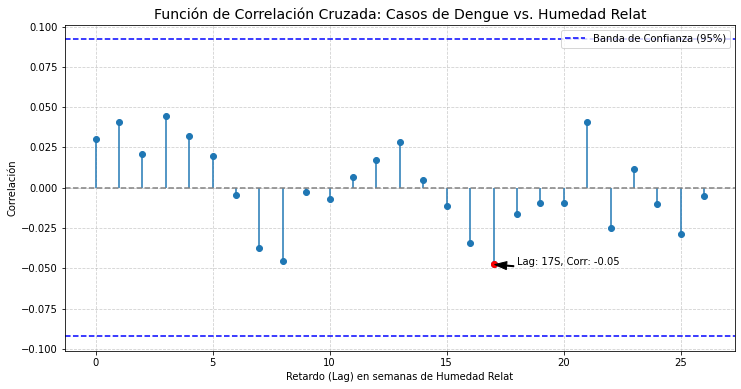

⚠️ Aplicando diff() a  La Habana


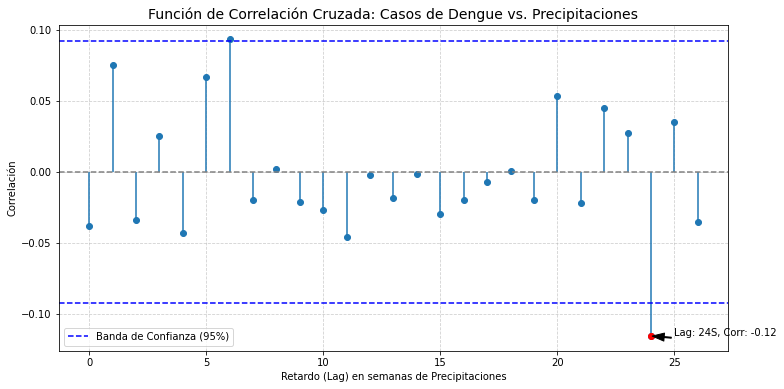

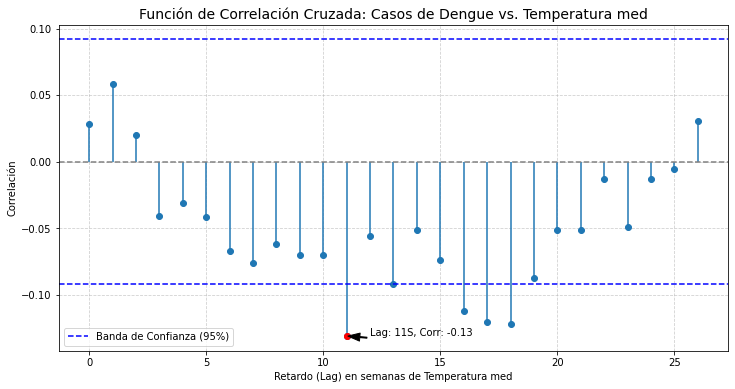

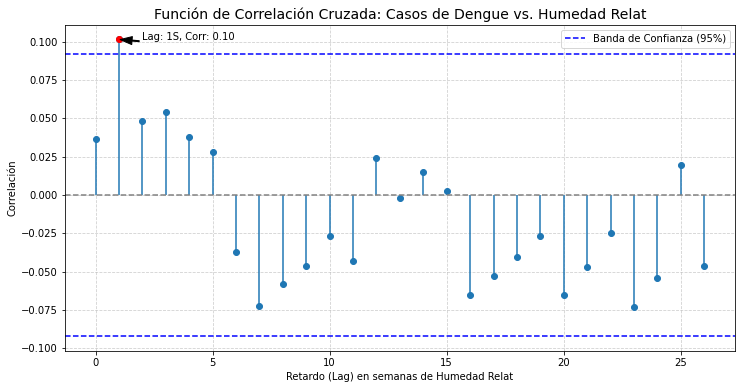

⚠️ Aplicando diff() a  Las Tunas


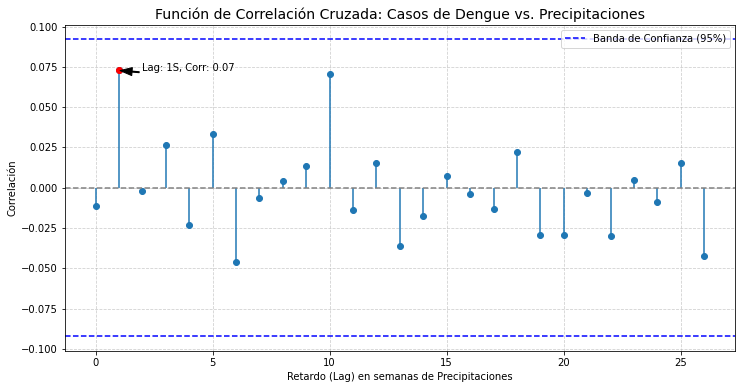

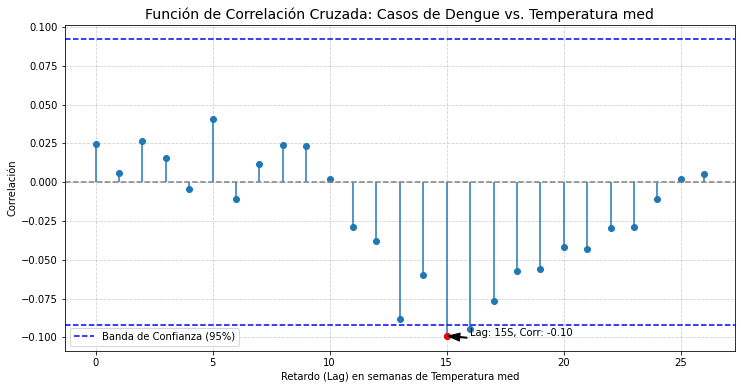

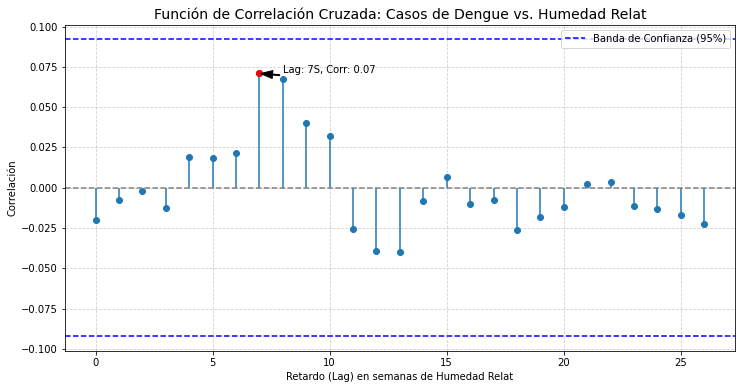

⚠️ Aplicando diff() a  Matanzas


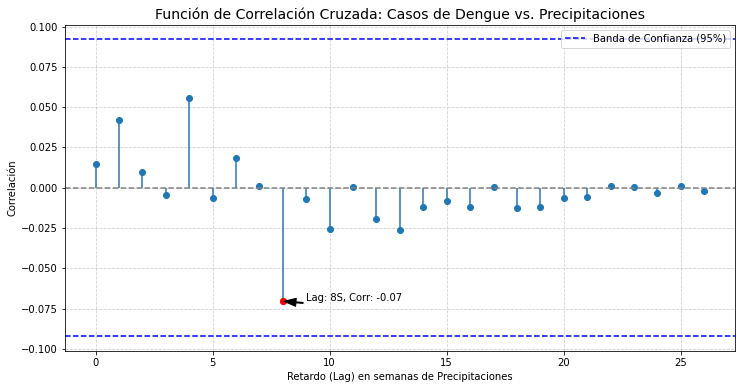

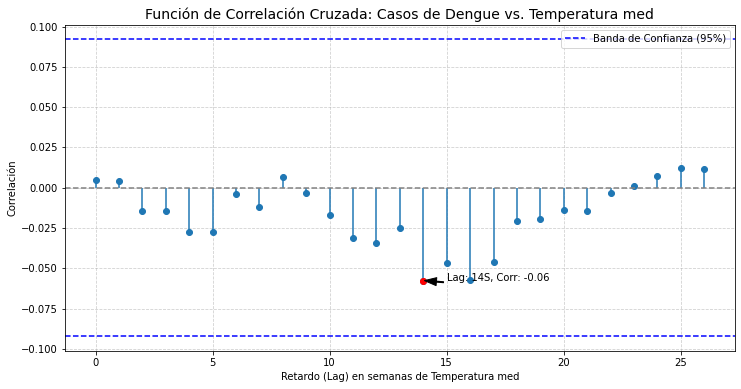

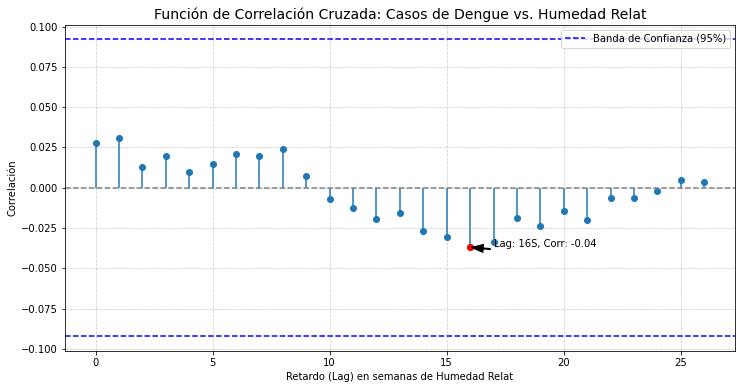

⚠️ Aplicando diff() a  Mayabeque


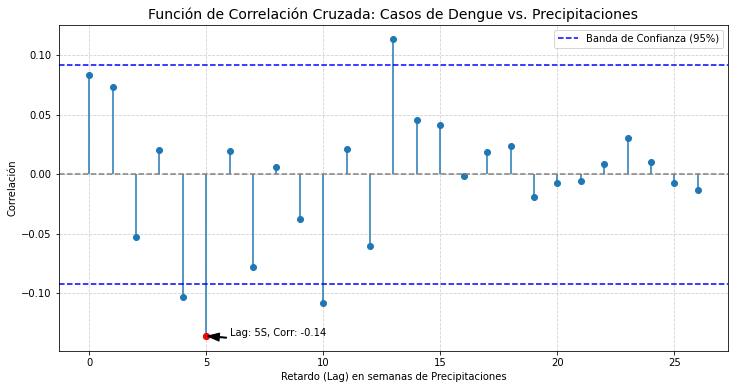

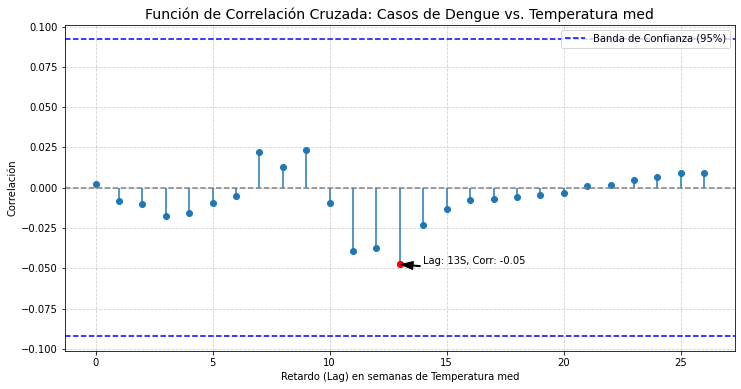

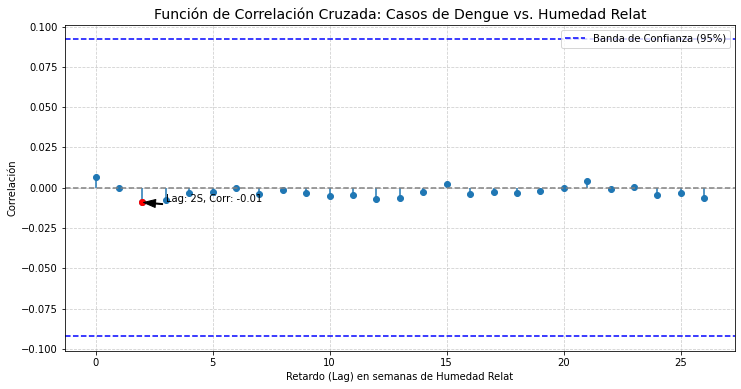

⚠️ Aplicando diff() a  Pinar del Río


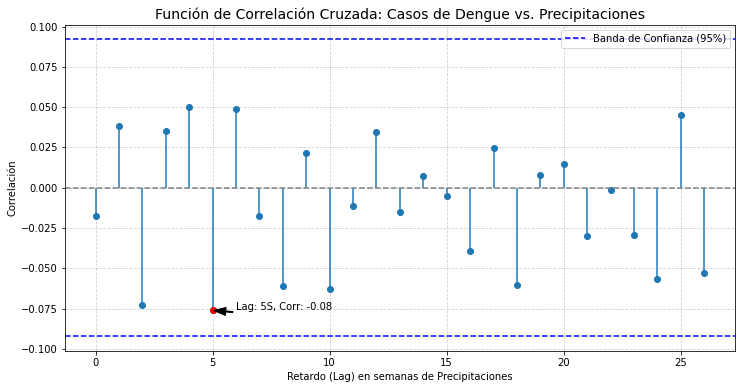

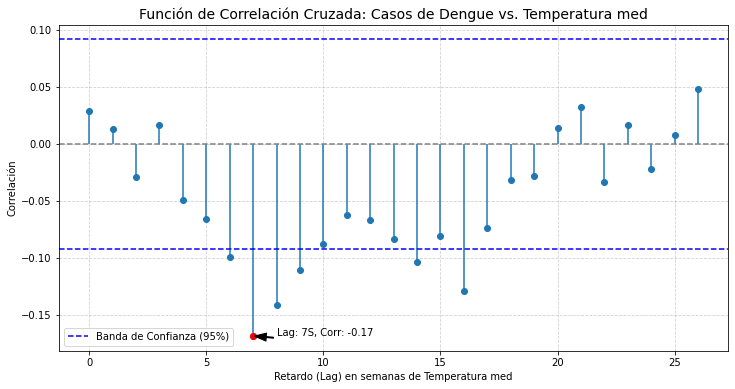

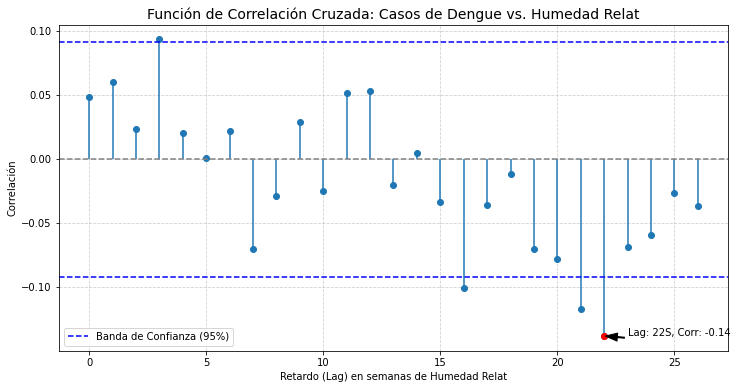

⚠️ Aplicando diff() a  Sancti Spíritus


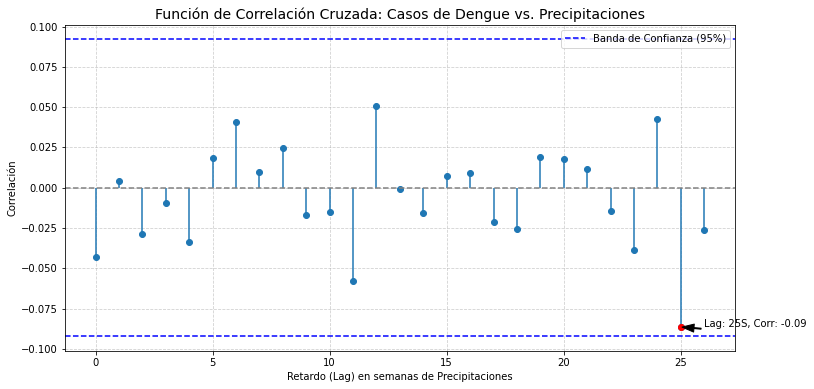

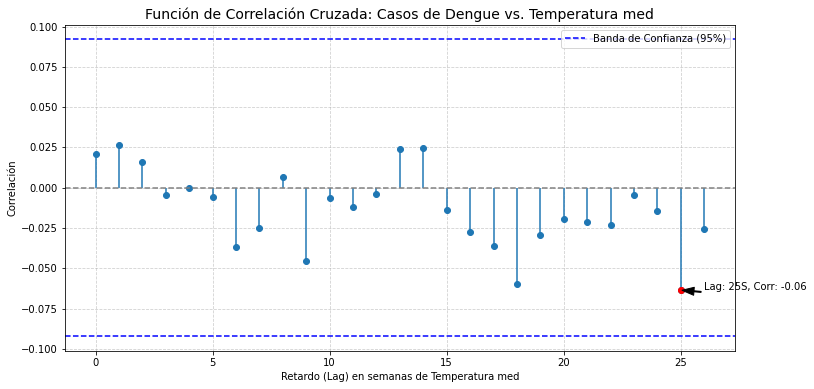

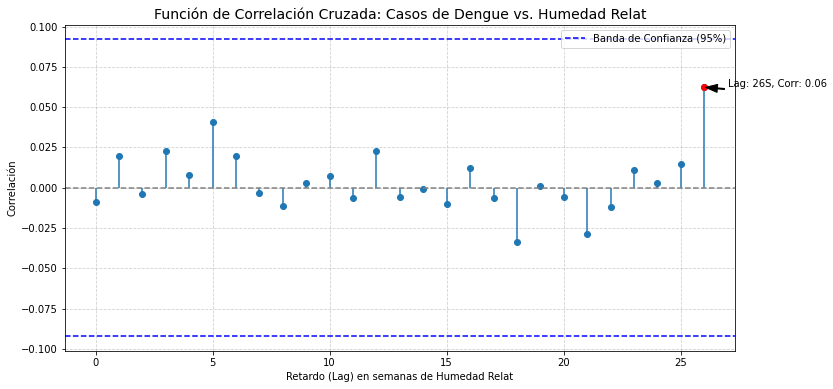

⚠️ Aplicando diff() a  Santiago de Cuba


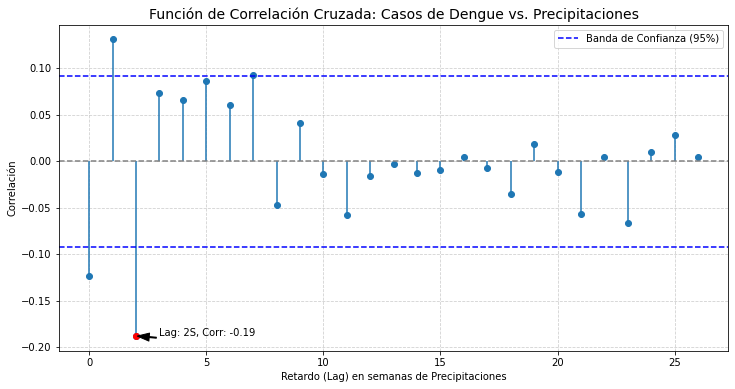

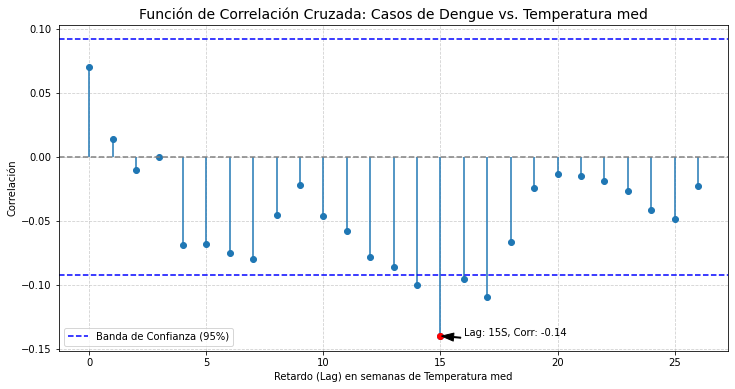

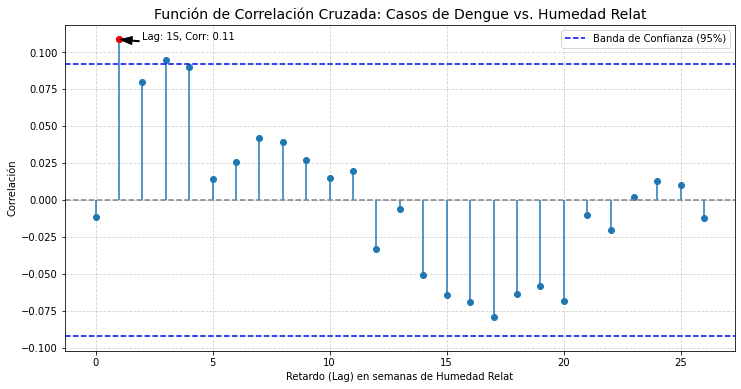

⚠️ Aplicando diff() a  Villa Clara


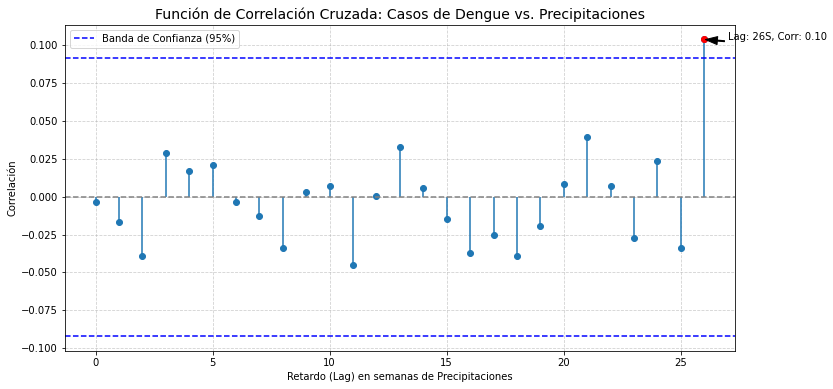

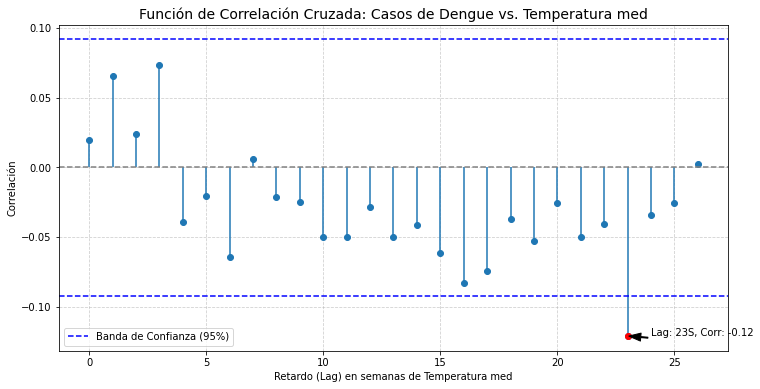

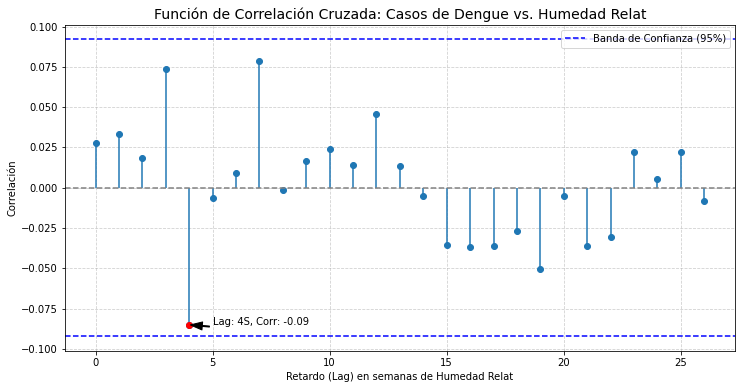

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import ccf
df_combinado=df_final
# Asumimos que df_combinado ya existe y está listo.
# Nos aseguramos de que 'Provincias' no sea el índice
if 'Provincias' not in df_combinado.columns:
    df_combinado = df_combinado.reset_index()

# --- Función para calcular y graficar la CCF ---
def graficar_ccf(serie1, serie2, nombre_serie1, nombre_serie2, max_lag=26):
    """
    Calcula y grafica la Función de Correlación Cruzada (CCF).
    
    Args:
        serie1 (pd.Series): Serie de tiempo principal (ej. Casos de Dengue).
        serie2 (pd.Series): Serie de tiempo secundaria (ej. Precipitaciones).
        nombre_serie1 (str): Nombre para la etiqueta de la serie 1.
        nombre_serie2 (str): Nombre para la etiqueta de la serie 2.
        max_lag (int): Número máximo de semanas de retardo a analizar.
    """
    # Eliminar valores NaN para que ccf funcione correctamente
    df_temp = pd.DataFrame({f'{nombre_serie1}': serie1, f'{nombre_serie2}': serie2}).dropna()
    s1 = df_temp[f'{nombre_serie1}']
    s2 = df_temp[f'{nombre_serie2}']
    
    # Calcular la CCF usando statsmodels
    # El orden importa: ccf(x, y) mide cómo x se correlaciona con y en lags de x
    ccf_values = ccf(s2, s1, adjusted=False)[:max_lag+1]
    
    # Crear el eje de lags (de 0 a max_lag)
    lags = np.arange(0, len(ccf_values))
    
    # Calcular las bandas de confianza
    n = len(s1)
    conf_level = 1.96 / np.sqrt(n)
    
    # --- Graficar ---
    plt.figure(figsize=(12, 6))
    plt.stem(lags, ccf_values, basefmt=" ")
    plt.axhline(0, color='gray', linestyle='--')
    plt.axhline(conf_level, color='blue', linestyle='--', label='Banda de Confianza (95%)')
    plt.axhline(-conf_level, color='blue', linestyle='--')
    
    # Encontrar y marcar el lag de máxima correlación
    max_corr_idx = np.argmax(np.abs(ccf_values))
    max_corr_lag = lags[max_corr_idx]
    max_corr_value = ccf_values[max_corr_idx]
    
    plt.plot(max_corr_lag, max_corr_value, 'ro') # Punto rojo en el máximo
    plt.annotate(f'Lag: {max_corr_lag}S, Corr: {max_corr_value:.2f}',
                 xy=(max_corr_lag, max_corr_value),
                 xytext=(max_corr_lag + 1, max_corr_value),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8))

    plt.title(f'Función de Correlación Cruzada: {nombre_serie1} vs. {nombre_serie2}', fontsize=14)
    plt.xlabel(f'Retardo (Lag) en semanas de {nombre_serie2}')
    plt.ylabel('Correlación')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()


for provincia in provincias:
    df_provincia = df_combinado[df_combinado['Provincias'] == provincia].copy()
    df_provincia = df_provincia.sort_index()

    serie_dengue = df_provincia['Casos_Dengue']
    
    if True:#provincia == "Matanzas":
        print("⚠️ Aplicando diff() a ",provincia)
        # Es fundamental que si aplicas diff a una, 
        # las variables climáticas correspondan a los mismos periodos.
        # Por eso creamos un dataframe temporal para alinear tras el diff
        df_temp = df_provincia[['Casos_Dengue'] + variables_climaticas].diff().dropna()
        serie_dengue = df_temp['Casos_Dengue']
    # else:
    #     print(provincia)
    #     df_temp = df_provincia[['Casos_Dengue'] + variables_climaticas]
    #     serie_dengue = df_temp['Casos_Dengue']
        
    for variable in variables_climaticas:
        # Llamar a la función para graficar la CCF
        graficar_ccf(
            serie1=serie_dengue,
            serie2=df_temp[variable],
            nombre_serie1='Casos de Dengue',
            nombre_serie2=variable,
            max_lag=26 # Analizar hasta 20 semanas de retardo
        )

In [50]:
from scipy.stats import pearsonr

def encontrar_TODOS_lags_significativos(serie_y, serie_x, nombre_x, max_lag=20, alpha=0.05):
    """
    Identifica todos los retardos que superan la prueba de hipótesis (p < 0.05)
    después de diferenciar las series.
    """
    # 1. Diferenciación y alineación inicial
    dy = serie_y.diff().dropna()
    dx = serie_x.diff().dropna()
    df_diff = pd.DataFrame({'dy': dy, 'dx': dx}).dropna()
    
    # 2. Calcular CCF para obtener los valores de correlación
    ccf_values = ccf(df_diff['dx'], df_diff['dy'], adjusted=False)[:max_lag+1]
    
    lags_validados = []

    # 3. Iterar por cada lag posible para validar su p-valor individualmente
    for lag in range(len(ccf_values)):
        r_ccf = ccf_values[lag]
        
        # Alinear series para este lag específico
        y_val = df_diff['dy'].iloc[lag:]
        x_val = df_diff['dx'].shift(lag).dropna()
        
        common_idx = y_val.index.intersection(x_val.index)
        
        if len(common_idx) > 5:
            _, p_val = pearsonr(x_val.loc[common_idx], y_val.loc[common_idx])
            
            if  abs(r_ccf) >= 0.05:
                if p_val < alpha:
                    lags_validados.append({
                        'variable': nombre_x,
                        'lag': lag,
                        'correlacion': r_ccf,
                        'p_valor': p_val
                    })
                
    return lags_validados

# --- Ejecución y Resumen ---
print(f"{'Provincia':<15} | {'Variable':<18} | {'Lags Validados (p < 0.05)'}")
print("-" * 70)

for provincia in provincias:
    df_p = df_combinado[df_combinado['Provincias'] == provincia].sort_index()
    
    for var in variables_climaticas:
        lags_encontrados = encontrar_TODOS_lags_significativos(df_p['Casos_Dengue'], df_p[var], var)
        
        if lags_encontrados:
            # Formateamos los lags para que se vean como: "Lag 4 (r:0.12), Lag 5 (r:0.15)"
            lags_str = ", ".join([f"L{l['lag']} (r:{l['correlacion']:.2f})" for l in lags_encontrados])
            print(f"{provincia:<15} | {var:<18} | {lags_str}")

Provincia       | Variable           | Lags Validados (p < 0.05)
----------------------------------------------------------------------
Artemisa        | Precipitaciones    | L5 (r:-0.11)
Camagüey        | Precipitaciones    | L5 (r:0.06), L9 (r:-0.13)
Holguín         | Precipitaciones    | L13 (r:-0.07)
La Habana       | Temperatura med    | L6 (r:-0.07)
Las Tunas       | Precipitaciones    | L10 (r:0.07)
Mayabeque       | Precipitaciones    | L5 (r:-0.14), L13 (r:0.11)
Pinar del Río   | Temperatura med    | L17 (r:-0.07)
Santiago de Cuba | Precipitaciones    | L0 (r:-0.12), L1 (r:0.13), L4 (r:0.07)
Santiago de Cuba | Temperatura med    | L6 (r:-0.07), L12 (r:-0.08), L13 (r:-0.09), L14 (r:-0.10), L15 (r:-0.14)
Villa Clara     | Temperatura med    | L6 (r:-0.06)


In [55]:
df_clima_t = df_clima_t.rename(columns={"Precip": "Precipitaciones","Temp_Med":"Temperatura med","Hum_Rel":'Humedad Relat'})


In [54]:
df_clima_t

,Provincias,Fecha,Temp_Med,Hum_Rel,Precip,Año,Mes
0,Artemisa,2014-01-06,21.7500,78.000,28.175,2014,1
1,Artemisa,2014-01-13,22.2375,77.875,28.175,2014,1
2,Artemisa,2014-01-20,22.7250,77.750,28.175,2014,1
3,Artemisa,2014-01-27,23.2125,77.625,28.175,2014,1
4,Artemisa,2014-02-03,23.7000,77.500,18.700,2014,2
...,...,...,...,...,...,...,...
7451,Villa Clara,2022-11-07,24.6000,83.000,15.500,2022,11
7452,Villa Clara,2022-11-14,24.0000,82.250,15.500,2022,11
7453,Villa Clara,2022-11-21,23.4000,81.500,15.500,2022,11
7454,Villa Clara,2022-11-28,22.8000,80.750,15.500,2022,11


In [ ]:
lags_por_provincia = {
    'Artemisa': {'Precipitaciones': [5]},  # L5
    'Camagüey': {'Precipitaciones': [5, 9]},  # L5, L9
    'Holguín': {'Precipitaciones': [13]},  # L13
    'La Habana': {'Temperatura med': [6]},  # L6
    'Las Tunas': {'Precipitaciones': [10]},  # L10
    'Mayabeque': {'Precipitaciones': [5, 13]},  # L5, L13
    'Pinar del Río': {'Temperatura med': [17]},  # L17
    'Santiago de Cuba': {
        'Precipitaciones': [0, 1, 4],  # L0, L1, L4
        'Temperatura med': [6, 12, 13, 14, 15]  # L6, L12, L13, L14, L15
    },
    'Villa Clara': {'Temperatura med': [6]},  # L6
}

In [ ]:
lista_procesada = []

for provincia, lags_dict in lags_por_provincia.items():
    print(f"--- Procesando provincia: {provincia} ---")
    
    dengue_prov = df_dengue_largo[df_dengue_largo['Provincias'] == provincia].copy()
    clima_prov = df_clima_t[df_clima_t['Provincias'] == provincia].copy()
    
    # Verificar que clima_prov no esté vacío
    if clima_prov.empty:
        print(f"  ¡Advertencia: No hay datos climáticos para {provincia}!")
        continue

    clima_con_lags = clima_prov.copy()
    
    # Iterar sobre las variables y sus lags
    for variable, lags_value in lags_dict.items():
        # Verificar si la variable existe en el DataFrame
        if variable not in clima_prov.columns:
            print(f"  ¡Advertencia: Variable '{variable}' no encontrada en clima_prov para {provincia}")
            continue
        
        # Determinar si lags_value es un solo número o una lista
        if isinstance(lags_value, list):
            # Es una lista de lags (nueva estructura)
            for lag in lags_value:
                nombre_columna_lag = f'{variable}_lag{lag}'
                clima_con_lags[nombre_columna_lag] = clima_prov[variable].shift(lag)
                print(f"  - Creada columna '{nombre_columna_lag}' con lag={lag}")
        else:
            # Es un solo lag (estructura anterior)
            lag = lags_value
            nombre_columna_lag = f'{variable}_lag{lag}'
            clima_con_lags[nombre_columna_lag] = clima_prov[variable].shift(lag)
            print(f"  - Creada columna '{nombre_columna_lag}' con lag={lag}")
        
    df_unido = pd.merge(dengue_prov, clima_con_lags, on=['Fecha', 'Provincias'], how='left')
    print(f"  Dimensiones del merge: {df_unido.shape}")
    lista_procesada.append(df_unido)
    print(df_unido)

# df_final = pd.concat(lista_procesada, ignore_index=True)

# print("\n¡Proceso completado!")
# print(f"Dimensiones del DataFrame final: {df_final.shape}")

# columnas_a_mostrar = ['Provincia', 'Casos_Dengue', 'Temperatura med_lag14', 'Precipitaciones_lag18']
# columnas_existentes = [col for col in columnas_a_mostrar if col in df_final.columns]
# print(df_final[columnas_existentes].head(50))

--- Procesando provincia: Artemisa ---
  - Creada columna 'Precipitaciones_lag5' con lag=5
  Dimensiones del merge: (458, 11)
     Año_x  Semana Estadística      Fecha Provincias  Casos_Dengue  \
0     2014                   1 2014-01-06   Artemisa           0.0   
1     2014                   2 2014-01-13   Artemisa           0.0   
2     2014                   3 2014-01-20   Artemisa           0.0   
3     2014                   4 2014-01-27   Artemisa           0.0   
4     2014                   5 2014-02-03   Artemisa           0.0   
..     ...                 ...        ...        ...           ...   
453   2022                  48 2022-11-28   Artemisa          37.0   
454   2022                  49 2022-12-05   Artemisa          28.0   
455   2022                  50 2022-12-12   Artemisa          24.0   
456   2022                  51 2022-12-19   Artemisa          19.0   
457   2022                  52 2022-12-26   Artemisa          15.0   

     Temperatura med  Humedad Rel

In [60]:
lista_procesada

[     Año_x  Semana Estadística      Fecha Provincias  Casos_Dengue  \
 0     2014                   1 2014-01-06   Artemisa           0.0   
 1     2014                   2 2014-01-13   Artemisa           0.0   
 2     2014                   3 2014-01-20   Artemisa           0.0   
 3     2014                   4 2014-01-27   Artemisa           0.0   
 4     2014                   5 2014-02-03   Artemisa           0.0   
 ..     ...                 ...        ...        ...           ...   
 453   2022                  48 2022-11-28   Artemisa          37.0   
 454   2022                  49 2022-12-05   Artemisa          28.0   
 455   2022                  50 2022-12-12   Artemisa          24.0   
 456   2022                  51 2022-12-19   Artemisa          19.0   
 457   2022                  52 2022-12-26   Artemisa          15.0   
 
      Temperatura med  Humedad Relat  Precipitaciones   Año_y   Mes  \
 0            21.7500         78.000           28.175  2014.0   1.0   
 1  

In [62]:
import pandas as pd

diccionario_de_dataframes = {}

for provincia, lags_dict in lags_por_provincia.items():
    print(f"Procesando: {provincia}...")
    
    dengue_prov = df_dengue_largo[df_dengue_largo['Provincias'] == provincia].copy()
    clima_prov = df_clima_t[df_clima_t['Provincias'] == provincia].copy()
    
    clima_con_lags = clima_prov.copy()
    
    # Handle multiple lags per variable
    for variable, lags in lags_dict.items():
        # Check if lags is a list (multiple lags) or a single value
        if isinstance(lags, list):
            for lag in lags:
                nombre_columna_lag = f'{variable}_lag{lag}'
                clima_con_lags[nombre_columna_lag] = clima_prov[variable].shift(lag)
        else:
            # Single lag value
            nombre_columna_lag = f'{variable}_lag{lags}'
            clima_con_lags[nombre_columna_lag] = clima_prov[variable].shift(lags)
    
    df_procesado = pd.merge(dengue_prov, clima_con_lags, on=['Fecha', 'Provincias'], how='left')
    
    df_procesado.dropna(inplace=True)
    
    if not df_procesado.empty:
        diccionario_de_dataframes[provincia] = df_procesado
        print(f"  -> DataFrame para '{provincia}' guardado con {len(df_procesado)} filas.")
    else:
        print(f"  -> ADVERTENCIA: El DataFrame para '{provincia}' quedó vacío.")

print("\n¡Proceso completado!")
print(f"Se han creado DataFrames para {len(diccionario_de_dataframes)} provincias.")

Procesando: Artemisa...
  -> DataFrame para 'Artemisa' guardado con 450 filas.
Procesando: Camagüey...
  -> DataFrame para 'Camagüey' guardado con 448 filas.
Procesando: Holguín...
  -> DataFrame para 'Holguín' guardado con 445 filas.
Procesando: La Habana...
  -> DataFrame para 'La Habana' guardado con 450 filas.
Procesando: Las Tunas...
  -> DataFrame para 'Las Tunas' guardado con 448 filas.
Procesando: Mayabeque...
  -> DataFrame para 'Mayabeque' guardado con 445 filas.
Procesando: Pinar del Río...
  -> DataFrame para 'Pinar del Río' guardado con 441 filas.
Procesando: Santiago de Cuba...
  -> DataFrame para 'Santiago de Cuba' guardado con 443 filas.
Procesando: Villa Clara...
  -> DataFrame para 'Villa Clara' guardado con 450 filas.

¡Proceso completado!
Se han creado DataFrames para 9 provincias.


In [63]:
import os

# Crear una carpeta para guardar los archivos si no existe
carpeta_salida = 'dataframes_con_lags'
os.makedirs(carpeta_salida, exist_ok=True)

for provincia, df in diccionario_de_dataframes.items():
    ruta_archivo = os.path.join(carpeta_salida, f'{provincia.replace(" ", "_")}.csv')
    df.to_csv(ruta_archivo) 
    print(f"DataFrame de '{provincia}' guardado en '{ruta_archivo}'")

print(f"\n¡Todos los DataFrames se guardaron en la carpeta '{carpeta_salida}'!")

DataFrame de 'Artemisa' guardado en 'dataframes_con_lags/Artemisa.csv'
DataFrame de 'Camagüey' guardado en 'dataframes_con_lags/Camagüey.csv'
DataFrame de 'Holguín' guardado en 'dataframes_con_lags/Holguín.csv'
DataFrame de 'La Habana' guardado en 'dataframes_con_lags/La_Habana.csv'
DataFrame de 'Las Tunas' guardado en 'dataframes_con_lags/Las_Tunas.csv'
DataFrame de 'Mayabeque' guardado en 'dataframes_con_lags/Mayabeque.csv'
DataFrame de 'Pinar del Río' guardado en 'dataframes_con_lags/Pinar_del_Río.csv'
DataFrame de 'Santiago de Cuba' guardado en 'dataframes_con_lags/Santiago_de_Cuba.csv'
DataFrame de 'Villa Clara' guardado en 'dataframes_con_lags/Villa_Clara.csv'

¡Todos los DataFrames se guardaron en la carpeta 'dataframes_con_lags'!
